<a href="https://colab.research.google.com/github/saniya-ahuja/Double-descent-app/blob/main/color_correction_L1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

raw_path = "/content/drive/MyDrive/Underwater_Project/raw-890/raw-890"
ref_path = "/content/drive/MyDrive/Underwater_Project/reference-890/reference-890"

print("Raw Images:", len(os.listdir(raw_path)))
print("Reference Images:", len(os.listdir(ref_path)))

Raw Images: 890
Reference Images: 890


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from PIL import Image

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

In [ ]:
raw_files = sorted(os.listdir(raw_path))
ref_files = sorted(os.listdir(ref_path))

print(len(raw_files))
print(len(ref_files))

890
890


In [ ]:
train_raw, test_raw, train_ref, test_ref = train_test_split(
    raw_files, ref_files, test_size = 0.2, random_state = 42
)
print("Train:", len(train_raw))
print("Test:", len(test_raw))

Train: 712
Test: 178


In [ ]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [ ]:
class UnderwaterDataset(Dataset):
  def __init__(self, raw_path, ref_path, raw_files, ref_files, transform = None):
    self.raw_path = raw_path
    self.ref_path = ref_path

    self.raw_files = raw_files
    self.ref_files = ref_files

    self.transform = transform

  def __len__(self):
      return len(self.raw_files)

  def __getitem__(self, idx):
      raw_img = Image.open(os.path.join(
          self.raw_path, self.raw_files[idx]
      )).convert("RGB")
      ref_img = Image.open(os.path.join(
          self.ref_path, self.ref_files[idx]
      )).convert("RGB")

      if self.transform:
        raw_img = self.transform(raw_img)
        ref_img = self.transform(ref_img)
      return raw_img, ref_img

In [ ]:
train_dataset = UnderwaterDataset(
    raw_path, ref_path, train_raw, train_ref, transform
)
test_dataset = UnderwaterDataset(
    raw_path, ref_path, test_raw, test_ref, transform
)
print(len(train_dataset))
print(len(test_dataset))

712
178


In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)

In [ ]:
raw_batch, ref_batch = next(iter(train_loader))

print(raw_batch.shape)
print(ref_batch.shape)

torch.Size([16, 3, 256, 256])
torch.Size([16, 3, 256, 256])


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

In [ ]:
import torch
import torch.nn as nn

class ColorAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // 2),
            nn.ReLU(inplace=True),
            nn.Linear(channels // 2, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        attn = self.attn(x).unsqueeze(-1).unsqueeze(-1)
        return x * attn

class GlobalColorPreFilter(nn.Module):
    """Learns a global pixel-wise color correction scaling factor at the input stage"""
    def __init__(self):
        super().__init__()
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(inplace=True),
            nn.Linear(8, 3),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Scale factor per RGB channel based on global scene context
        scale = self.global_pool(x).view(x.size(0), 3)
        scale = self.fc(scale).view(x.size(0), 3, 1, 1) * 2.0  # Allow up to 2x scaling
        return x * scale

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class TargetColorAttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 1. Front-end global color adjustment
        self.pre_filter = GlobalColorPreFilter()

        # Encoder
        self.enc1 = ConvBlock(3, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(128, 256)
        self.b_attn = ColorAttention(256)

        # 2. Multi-scale Attention Modules applied specifically to Skip Connections
        self.skip_attn3 = ColorAttention(128)
        self.skip_attn2 = ColorAttention(64)
        self.skip_attn1 = ColorAttention(32)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.output = nn.Sequential(
            nn.Conv2d(32, 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Apply pre-filtering for global illumination/color adjustments
        x_filtered = self.pre_filter(x)

        # Encoder passes
        e1 = self.enc1(x_filtered)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))
        b = self.b_attn(b)

        # Decoder passes with Color Attention on the skip branches
        d3 = self.up3(b)
        attn_e3 = self.skip_attn3(e3)  # Color correction at 128-channel scale
        d3 = self.dec3(torch.cat([d3, attn_e3], dim=1))

        d2 = self.up2(d3)
        attn_e2 = self.skip_attn2(e2)  # Color correction at 64-channel scale
        d2 = self.dec2(torch.cat([d2, attn_e2], dim=1))

        d1 = self.up1(d2)
        attn_e1 = self.skip_attn1(e1)  # Color correction at 32-channel scale
        d1 = self.dec1(torch.cat([d1, attn_e1], dim=1))

        return self.output(d1)


In [ ]:
model = TargetColorAttentionUNet().to(device)
print(model)

TargetColorAttentionUNet(
  (pre_filter): GlobalColorPreFilter(
    (global_pool): AdaptiveAvgPool2d(output_size=1)
    (fc): Sequential(
      (0): Linear(in_features=3, out_features=8, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=8, out_features=3, bias=True)
      (3): Sigmoid()
    )
  )
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UIEBOptimizedLoss(nn.Module):
    def __init__(self, pixel_weight=1.0, color_weight=0.5, edge_weight=0.2):
        super().__init__()
        self.pixel_weight = pixel_weight
        self.color_weight = color_weight
        self.edge_weight = edge_weight

        # 1. Base Pixel Loss (Replaced MSE with L1)
        self.l1 = nn.L1Loss()

        # 3. Setup for Edge/Structural Loss using Sobel Filters
        # These fixed convolutional weights detect horizontal and vertical edges
        k_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
        k_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)

        # We register them as buffers so they move to the GPU automatically but aren't trained
        self.register_buffer('sobel_x', k_x.repeat(3, 1, 1, 1)) # Repeat for RGB
        self.register_buffer('sobel_y', k_y.repeat(3, 1, 1, 1))

    def compute_edge_map(self, img):
        # Apply Sobel filters to extract structural edges
        # Move the static sobel filters to the same device as the input image (e.g. cuda:0)
        sobel_x = self.sobel_x.to(img.device)
        sobel_y = self.sobel_y.to(img.device)

        # Groups=3 applies the filter to each RGB channel independently
        grad_x = F.conv2d(img, sobel_x, padding=1, groups=3)
        grad_y = F.conv2d(img, sobel_y, padding=1, groups=3)
        # Combine X and Y gradients to get the final edge map
        edge_map = torch.sqrt(grad_x**2 + grad_y**2 + 1e-6)
        return edge_map

    def forward(self, pred, target):
        # --- 1. PIXEL LOSS ---
        # Keeps overall image accurate without blurring like MSE
        pixel_loss = self.l1(pred, target)

        # --- 2. COLOR LOSS (Cosine Similarity) ---
        # Flattens spatial dimensions to treat RGB as 3D vectors: (Batch, 3, Pixels)
        pred_flat = pred.view(pred.shape[0], 3, -1)
        target_flat = target.view(target.shape[0], 3, -1)

        # Cosine similarity gives 1 for identical colors and -1 for opposites.
        # We want to minimize the loss, so we subtract it from 1.
        cos_sim = F.cosine_similarity(pred_flat, target_flat, dim=1)
        color_loss = torch.mean(1.0 - cos_sim)

        # --- 3. EDGE / STRUCTURAL LOSS ---
        # Forces the network to preserve sharp details like fish scales and coral texture
        pred_edges = self.compute_edge_map(pred)
        target_edges = self.compute_edge_map(target)
        edge_loss = self.l1(pred_edges, target_edges)

        # --- COMBINED TOTAL LOSS ---
        total_loss = (self.pixel_weight * pixel_loss) + \
                     (self.color_weight * color_loss) + \
                     (self.edge_weight * edge_loss)

        return total_loss

In [ ]:
criterion = UIEBOptimizedLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
num_epochs = 100

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for raw_imgs, ref_imgs in train_loader:

        raw_imgs = raw_imgs.to(device)
        ref_imgs = ref_imgs.to(device)

        optimizer.zero_grad()

        outputs = model(raw_imgs)

        loss = criterion(
            outputs,
            ref_imgs
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [10/100] Loss: 0.1076
Epoch [20/100] Loss: 0.0926
Epoch [30/100] Loss: 0.0868
Epoch [40/100] Loss: 0.0841
Epoch [50/100] Loss: 0.0804
Epoch [60/100] Loss: 0.0789
Epoch [70/100] Loss: 0.0778
Epoch [80/100] Loss: 0.0755
Epoch [90/100] Loss: 0.0727
Epoch [100/100] Loss: 0.0723


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Underwater_Project/unet_full_dataset.pth')
print("✅ Training complete & saved!")

✅ Training complete & saved!


In [ ]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [ ]:
model.eval()

psnr_list = []
ssim_list = []

with torch.no_grad():

    for raw_imgs, ref_imgs in test_loader:

        raw_imgs = raw_imgs.to(device)

        outputs = model(raw_imgs)

        outputs = outputs.cpu().numpy()
        refs = ref_imgs.numpy()

        for pred, target in zip(outputs, refs):

            pred = np.transpose(pred, (1,2,0))
            target = np.transpose(target, (1,2,0))

            psnr = peak_signal_noise_ratio(
                target,
                pred,
                data_range=1.0
            )

            ssim = structural_similarity(
                target,
                pred,
                channel_axis=2,
                data_range=1.0
            )

            psnr_list.append(psnr)
            ssim_list.append(ssim)

In [ ]:
print("Average PSNR:", np.mean(psnr_list))
print("Average SSIM:", np.mean(ssim_list))

Average PSNR: 22.326069615290777
Average SSIM: 0.88097674


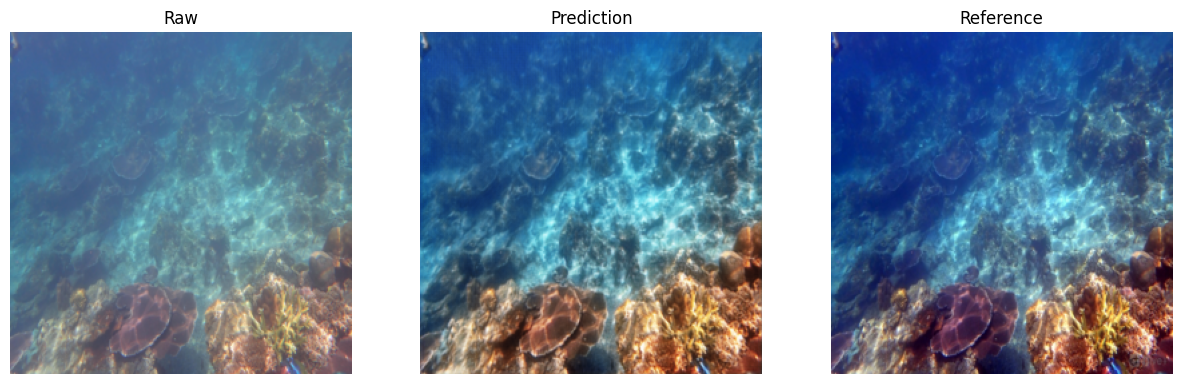

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Helper function to safely handle both Tensors and NumPy arrays
def format_for_plot(img):
    if torch.is_tensor(img):
        # Detach from graph, move to CPU, swap dims (CHW -> HWC), to numpy
        img = img.detach().cpu().permute(1, 2, 0).numpy()
    elif isinstance(img, np.ndarray) and img.shape[0] == 3:
        # If it's already a NumPy array but in CHW format, just transpose
        img = img.transpose(1, 2, 0)

    # Clip values to [0, 1] to prevent matplotlib warning glitches
    return np.clip(img, 0, 1)

raw = format_for_plot(raw_imgs[0])
pred = format_for_plot(outputs[0])
target = format_for_plot(ref_imgs[0])

axes[0].imshow(raw)
axes[0].set_title("Raw")
axes[0].axis("off")

axes[1].imshow(pred)
axes[1].set_title("Prediction")
axes[1].axis("off")

axes[2].imshow(target)
axes[2].set_title("Reference")
axes[2].axis("off")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

raw_path = "/content/drive/MyDrive/Underwater_Project/raw-890/raw-890"
ref_path = "/content/drive/MyDrive/Underwater_Project/reference-890/reference-890"

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from PIL import Image

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

In [ ]:
raw_files = sorted(os.listdir(raw_path))
ref_files = sorted(os.listdir(ref_path))

print(len(raw_files))
print(len(ref_files))


890
890


In [ ]:
train_raw, test_raw, train_ref, test_ref = train_test_split(
    raw_files, ref_files, test_size = 0.2, random_state = 42
)
print("Train:", len(train_raw))
print("Test:", len(test_raw))

Train: 712
Test: 178


In [ ]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])


In [ ]:
class UnderwaterDataset(Dataset):
  def __init__(self, raw_path, ref_path, raw_files, ref_files, transform = None):
    self.raw_path = raw_path
    self.ref_path = ref_path

    self.raw_files = raw_files
    self.ref_files = ref_files

    self.transform = transform

  def __len__(self):
      return len(self.raw_files)

  def __getitem__(self, idx):
      raw_img = Image.open(os.path.join(
          self.raw_path, self.raw_files[idx]
      )).convert("RGB")
      ref_img = Image.open(os.path.join(
          self.ref_path, self.ref_files[idx]
      )).convert("RGB")

      if self.transform:
        raw_img = self.transform(raw_img)
        ref_img = self.transform(ref_img)
      return raw_img, ref_img

In [ ]:
train_dataset = UnderwaterDataset(
    raw_path, ref_path, train_raw, train_ref, transform
)
test_dataset = UnderwaterDataset(
    raw_path, ref_path, test_raw, test_ref, transform
)
print(len(train_dataset))
print(len(test_dataset))

712
178


In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)

In [ ]:
raw_batch, ref_batch = next(iter(train_loader))

print(raw_batch.shape)
print(ref_batch.shape)

torch.Size([16, 3, 256, 256])
torch.Size([16, 3, 256, 256])


In [ ]:

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 1. NEW ADVANCED MODULES
# ==========================================

class DifferentiableRedRecovery(nn.Module):
    """Change 1: Red Channel Recovery using a differentiable Iqbal formula"""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        r, g, b = x[:, 0:1, ...], x[:, 1:2, ...], x[:, 2:3, ...]

        # Calculate global means per image
        mean_r = torch.mean(r, dim=[2, 3], keepdim=True)
        mean_g = torch.mean(g, dim=[2, 3], keepdim=True)

        # Only boost red if green is stronger (standard underwater case)
        # Using ReLU to make sure we don't accidentally darken red
        boost = torch.relu(mean_g - mean_r)

        # Proportional red compensation (Differentiable)
        r_new = r + boost * (1.0 - r) * g
        return torch.cat([r_new, g, b], dim=1)

class WaterTypeConditioning(nn.Module):
    """Change 2: Water Type Conditioning (Coastal Green vs. Ocean Blue)"""
    def __init__(self, channels):
        super().__init__()
        self.water_analyzer = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), # Look at the global color cast
            nn.Flatten(),
            nn.Linear(3, 16),
            nn.ReLU(inplace=True),
            nn.Linear(16, channels),
            nn.Sigmoid()
        )

    def forward(self, feature_map, raw_image):
        # Analyze the raw image to find the water type (blue vs green)
        water_type_weights = self.water_analyzer(raw_image).unsqueeze(-1).unsqueeze(-1)
        # Scale the bottleneck features up to 2x based on the water type
        return feature_map * (water_type_weights * 2.0)

class InstanceConvBlock(nn.Module):
    """Change 3: Using InstanceNorm instead of BatchNorm"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), # affine=True allows it to learn scaling
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

# ==========================================
# 2. THE PHYSICS-AWARE ARCHITECTURE
# ==========================================

class PhysicsAwareUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Front-end explicit physics correction
        self.red_recovery = DifferentiableRedRecovery()

        # Encoder (Using InstanceNorm blocks)
        self.enc1 = InstanceConvBlock(3, 32)
        self.enc2 = InstanceConvBlock(32, 64)
        self.enc3 = InstanceConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck + Water Type Conditioning
        self.bottleneck = InstanceConvBlock(128, 256)
        self.water_cond = WaterTypeConditioning(256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = InstanceConvBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = InstanceConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = InstanceConvBlock(64, 32)

        self.output = nn.Sequential(
            nn.Conv2d(32, 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x_raw):
        # 1. Physics-guided red compensation
        x_recovered = self.red_recovery(x_raw)

        # 2. Encoder
        e1 = self.enc1(x_recovered)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # 3. Bottleneck with Water-Type awareness!
        b = self.bottleneck(self.pool(e3))
        b = self.water_cond(b, x_raw) # Pass raw image to analyze water type

        # 4. Decoder
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.output(d1)

# ==========================================
# 3. THE PHYSICS-GUIDED LOSS
# ==========================================

class PhysicsUIEBLoss(nn.Module):
    def __init__(self, pixel_w=1.0, color_w=0.5, edge_w=0.2, physics_w=0.1):
        super().__init__()
        self.pixel_w = pixel_w
        self.color_w = color_w
        self.edge_w = edge_w
        self.physics_w = physics_w # New Physics Weight
        self.l1 = nn.L1Loss()

        # Sobel Filters for Edge Loss
        k_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
        k_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)
        self.register_buffer('sobel_x', k_x.repeat(3, 1, 1, 1))
        self.register_buffer('sobel_y', k_y.repeat(3, 1, 1, 1))

    def compute_edge_map(self, img):
        grad_x = F.conv2d(img, self.sobel_x.to(img.device), padding=1, groups=3)
        grad_y = F.conv2d(img, self.sobel_y.to(img.device), padding=1, groups=3)
        return torch.sqrt(grad_x**2 + grad_y**2 + 1e-6)

    def dark_channel_prior(self, img):
        """Change 4: Physics Loss (Dark Channel Prior)
        In a clear image, the darkest pixel in a local patch should be close to 0.
        By minimizing this, we force the network to remove the white/gray haze.
        """
        # 1. Get minimum value across RGB channels
        min_channels, _ = torch.min(img, dim=1, keepdim=True)
        # 2. Get minimum value in local 15x15 patches (using trick: -max_pool(-x))
        dcp = -F.max_pool2d(-min_channels, kernel_size=15, stride=1, padding=7)
        return dcp

    def forward(self, pred, target):
        # 1. Pixel Loss
        pixel_loss = self.l1(pred, target)

        # 2. Color Loss
        pred_flat = pred.view(pred.shape[0], 3, -1)
        target_flat = target.view(target.shape[0], 3, -1)
        cos_sim = F.cosine_similarity(pred_flat, target_flat, dim=1)
        color_loss = torch.mean(1.0 - cos_sim)

        # 3. Edge Loss
        edge_loss = self.l1(self.compute_edge_map(pred), self.compute_edge_map(target))

        # 4. NEW: Physics Haze Loss (DCP)
        # We want the network's prediction to have a Dark Channel similar to the target image
        pred_dcp = self.dark_channel_prior(pred)
        target_dcp = self.dark_channel_prior(target)
        physics_loss = self.l1(pred_dcp, target_dcp)

        # Combined Loss
        total = (self.pixel_w * pixel_loss) + \
                (self.color_w * color_loss) + \
                (self.edge_w * edge_loss) + \
                (self.physics_w * physics_loss)

        return total

In [ ]:
model = PhysicsAwareUNet().to(device)
print(model)

PhysicsAwareUNet(
  (red_recovery): DifferentiableRedRecovery()
  (enc1): InstanceConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): InstanceConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [ ]:
criterion = PhysicsUIEBLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
num_epochs = 100

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for raw_imgs, ref_imgs in train_loader:

        raw_imgs = raw_imgs.to(device)
        ref_imgs = ref_imgs.to(device)

        optimizer.zero_grad()

        outputs = model(raw_imgs)

        loss = criterion(
            outputs,
            ref_imgs
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [10/100] Loss: 0.1209
Epoch [20/100] Loss: 0.1018
Epoch [30/100] Loss: 0.0898
Epoch [40/100] Loss: 0.0793
Epoch [50/100] Loss: 0.0708
Epoch [60/100] Loss: 0.0657
Epoch [70/100] Loss: 0.0620
Epoch [80/100] Loss: 0.0574
Epoch [90/100] Loss: 0.0544
Epoch [100/100] Loss: 0.0516


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Underwater_Project/unet_full_dataset.pth')
print("✅ Training complete & saved!")

✅ Training complete & saved!


In [ ]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [ ]:
model.eval()

psnr_list = []
ssim_list = []

with torch.no_grad():

    for raw_imgs, ref_imgs in test_loader:

        raw_imgs = raw_imgs.to(device)

        outputs = model(raw_imgs)

        outputs = outputs.cpu().numpy()
        refs = ref_imgs.numpy()

        for pred, target in zip(outputs, refs):

            pred = np.transpose(pred, (1,2,0))
            target = np.transpose(target, (1,2,0))

            psnr = peak_signal_noise_ratio(
                target,
                pred,
                data_range=1.0
            )

            ssim = structural_similarity(
                target,
                pred,
                channel_axis=2,
                data_range=1.0
            )

            psnr_list.append(psnr)
            ssim_list.append(ssim)

In [ ]:
print("Average PSNR:", np.mean(psnr_list))
print("Average SSIM:", np.mean(ssim_list))

Average PSNR: 22.179176851074384
Average SSIM: 0.8717794


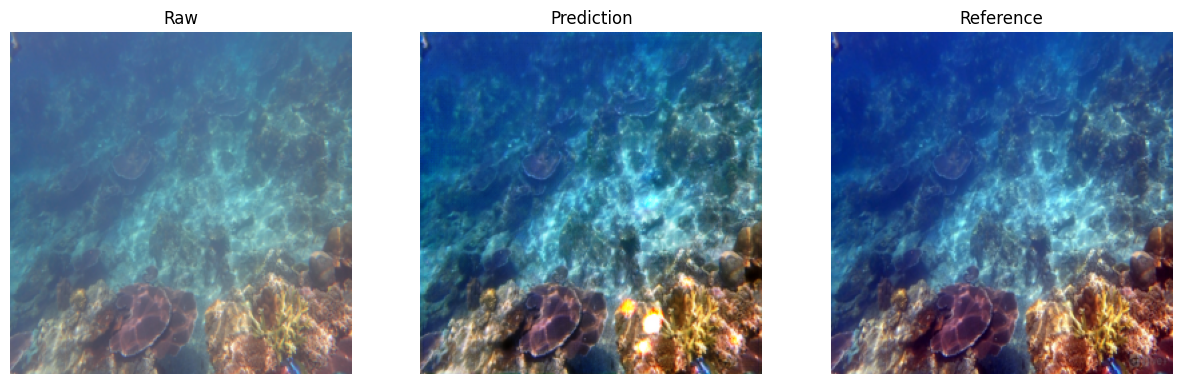

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Helper function to safely handle both Tensors and NumPy arrays
def format_for_plot(img):
    if torch.is_tensor(img):
        # Detach from graph, move to CPU, swap dims (CHW -> HWC), to numpy
        img = img.detach().cpu().permute(1, 2, 0).numpy()
    elif isinstance(img, np.ndarray) and img.shape[0] == 3:
        # If it's already a NumPy array but in CHW format, just transpose
        img = img.transpose(1, 2, 0)

    # Clip values to [0, 1] to prevent matplotlib warning glitches
    return np.clip(img, 0, 1)

raw = format_for_plot(raw_imgs[0])
pred = format_for_plot(outputs[0])
target = format_for_plot(ref_imgs[0])

axes[0].imshow(raw)
axes[0].set_title("Raw")
axes[0].axis("off")

axes[1].imshow(pred)
axes[1].set_title("Prediction")
axes[1].axis("off")

axes[2].imshow(target)
axes[2].set_title("Reference")
axes[2].axis("off")

plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

raw_path = "/content/drive/MyDrive/Underwater_Project/raw-890/raw-890"
ref_path = "/content/drive/MyDrive/Underwater_Project/reference-890/reference-890"

print("Raw Images:", len(os.listdir(raw_path)))
print("Reference Images:", len(os.listdir(ref_path)))

Raw Images: 890
Reference Images: 890


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from sklearn.model_selection import train_test_split

In [4]:
raw_files = sorted(os.listdir(raw_path))
ref_files = sorted(os.listdir(ref_path))

print(len(raw_files))
print(len(ref_files))

890
890


In [5]:
train_raw, test_raw, train_ref, test_ref = train_test_split(
    raw_files, ref_files, test_size=0.2, random_state=42
)
print("Train:", len(train_raw))
print("Test:", len(test_raw))

Train: 712
Test: 178


In [6]:
class UnderwaterDataset(Dataset):
    def __init__(self, raw_path, ref_path, raw_files, ref_files, img_size=256, augment=False):
        self.raw_path = raw_path
        self.ref_path = ref_path
        self.raw_files = raw_files
        self.ref_files = ref_files
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.raw_files)

    def __getitem__(self, idx):
        raw_img = Image.open(os.path.join(self.raw_path, self.raw_files[idx])).convert("RGB")
        ref_img = Image.open(os.path.join(self.ref_path, self.ref_files[idx])).convert("RGB")

        raw_img = TF.resize(raw_img, (self.img_size, self.img_size))
        ref_img = TF.resize(ref_img, (self.img_size, self.img_size))

        if self.augment:
            # Same random decision applied to BOTH images so pairs stay aligned
            if random.random() > 0.5:
                raw_img = TF.hflip(raw_img)
                ref_img = TF.hflip(ref_img)
            if random.random() > 0.5:
                raw_img = TF.vflip(raw_img)
                ref_img = TF.vflip(ref_img)
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                raw_img = TF.rotate(raw_img, angle)
                ref_img = TF.rotate(ref_img, angle)

        raw_img = TF.to_tensor(raw_img)
        ref_img = TF.to_tensor(ref_img)

        return raw_img, ref_img

In [7]:
train_dataset = UnderwaterDataset(raw_path, ref_path, train_raw, train_ref, img_size=256, augment=True)
test_dataset = UnderwaterDataset(raw_path, ref_path, test_raw, test_ref, img_size=256, augment=False)
print(len(train_dataset))
print(len(test_dataset))

712
178


In [8]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

In [9]:
raw_batch, ref_batch = next(iter(train_loader))
print(raw_batch.shape)
print(ref_batch.shape)

torch.Size([16, 3, 256, 256])
torch.Size([16, 3, 256, 256])


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [11]:
class HINBlock(nn.Module):
    """Half-Instance-Norm conv block. Normalizes only half the output
    channels, leaving the other half untouched so global color/brightness
    statistics survive instead of being stripped at every layer.
    Includes a residual path for healthier gradient flow."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.half = out_ch // 2
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.norm = nn.InstanceNorm2d(self.half, affine=True)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.relu2 = nn.ReLU(inplace=True)
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.residual(x)
        out = self.conv1(x)
        normed, raw = torch.split(out, [self.half, out.shape[1] - self.half], dim=1)
        normed = self.norm(normed)
        out = torch.cat([normed, raw], dim=1)
        out = self.relu1(out)
        out = self.conv2(out)
        return self.relu2(out) + res


class DifferentiableRedRecovery(nn.Module):
    """Red channel recovery via differentiable Iqbal-style compensation. Parameter-free physics prior."""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
        mean_r = torch.mean(r, dim=[2, 3], keepdim=True)
        mean_g = torch.mean(g, dim=[2, 3], keepdim=True)
        boost = torch.relu(mean_g - mean_r)
        r_new = r + boost * (1.0 - r) * g
        return torch.cat([r_new, g, b], dim=1)


class GlobalColorFiLM(nn.Module):
    """Predicts a per-image (scale, shift) from the RAW image's global color
    statistics and applies it via FiLM. Initialized near-identity so training
    starts gently. Called at points with no normalization afterward, so the
    per-image correction survives to the output."""
    def __init__(self, channels, hidden=32):
        super().__init__()
        self.channels = channels
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(3, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels * 2)
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, feat, raw_image):
        params = self.net(raw_image)
        gamma, beta = params.chunk(2, dim=1)
        gamma = gamma.unsqueeze(-1).unsqueeze(-1)
        beta = beta.unsqueeze(-1).unsqueeze(-1)
        return feat * (1.0 + gamma) + beta


class PhysicsAwareUNetV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.red_recovery = DifferentiableRedRecovery()

        self.enc1 = HINBlock(3, 32)
        self.enc2 = HINBlock(32, 64)
        self.enc3 = HINBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = HINBlock(128, 256)
        self.bottleneck_film = GlobalColorFiLM(256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = HINBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = HINBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = HINBlock(64, 32)

        self.output_film = GlobalColorFiLM(32)
        self.output = nn.Sequential(
            nn.Conv2d(32, 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x_raw):
        x_recovered = self.red_recovery(x_raw)

        e1 = self.enc1(x_recovered)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))
        b = self.bottleneck_film(b, x_raw)

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        d1 = self.output_film(d1, x_raw)
        return self.output(d1)

In [12]:
model = PhysicsAwareUNetV2().to(device)
print(model)
print("Param count:", sum(p.numel() for p in model.parameters()))

PhysicsAwareUNetV2(
  (red_recovery): DifferentiableRedRecovery()
  (enc1): HINBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (relu2): ReLU(inplace=True)
    (residual): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (enc2): HINBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (relu2): ReLU(inplace=True)
    (residual): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (enc3): HINBlock(
    (conv1): Conv2d(64, 128,

In [13]:
class PhysicsUIEBLoss(nn.Module):
    def __init__(self, pixel_w=1.0, color_w=0.5, edge_w=0.2, physics_w=0.1):
        super().__init__()
        self.pixel_w = pixel_w
        self.color_w = color_w
        self.edge_w = edge_w
        self.physics_w = physics_w
        self.l1 = nn.L1Loss()

        k_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
        k_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)
        self.register_buffer('sobel_x', k_x.repeat(3, 1, 1, 1))
        self.register_buffer('sobel_y', k_y.repeat(3, 1, 1, 1))

    def compute_edge_map(self, img):
        grad_x = F.conv2d(img, self.sobel_x.to(img.device), padding=1, groups=3)
        grad_y = F.conv2d(img, self.sobel_y.to(img.device), padding=1, groups=3)
        return torch.sqrt(grad_x**2 + grad_y**2 + 1e-6)

    def dark_channel_prior(self, img):
        min_channels, _ = torch.min(img, dim=1, keepdim=True)
        dcp = -F.max_pool2d(-min_channels, kernel_size=15, stride=1, padding=7)
        return dcp

    def forward(self, pred, target):
        pixel_loss = self.l1(pred, target)

        pred_flat = pred.view(pred.shape[0], 3, -1)
        target_flat = target.view(target.shape[0], 3, -1)
        cos_sim = F.cosine_similarity(pred_flat, target_flat, dim=1)
        color_loss = torch.mean(1.0 - cos_sim)

        edge_loss = self.l1(self.compute_edge_map(pred), self.compute_edge_map(target))

        pred_dcp = self.dark_channel_prior(pred)
        target_dcp = self.dark_channel_prior(target)
        physics_loss = self.l1(pred_dcp, target_dcp)

        total = (self.pixel_w * pixel_loss) + \
                (self.color_w * color_loss) + \
                (self.edge_w * edge_loss) + \
                (self.physics_w * physics_loss)
        return total

In [14]:
criterion = PhysicsUIEBLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_598/731374738.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [15]:
num_epochs = 100

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for raw_imgs, ref_imgs in train_loader:

        raw_imgs = raw_imgs.to(device, non_blocking=True)
        ref_imgs = ref_imgs.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(raw_imgs)
            loss = criterion(outputs, ref_imgs)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    scheduler.step()

    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f}  LR: {current_lr:.6f}")

/tmp/ipykernel_598/3137990437.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [10/100] Loss: 0.0924  LR: 0.000098
Epoch [20/100] Loss: 0.0829  LR: 0.000090
Epoch [30/100] Loss: 0.0774  LR: 0.000079
Epoch [40/100] Loss: 0.0735  LR: 0.000065
Epoch [50/100] Loss: 0.0675  LR: 0.000050
Epoch [60/100] Loss: 0.0628  LR: 0.000035
Epoch [70/100] Loss: 0.0593  LR: 0.000021
Epoch [80/100] Loss: 0.0575  LR: 0.000010
Epoch [90/100] Loss: 0.0560  LR: 0.000002
Epoch [100/100] Loss: 0.0559  LR: 0.000000


In [16]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Underwater_Project/unet_full_dataset_v2.pth')
print("Training complete & saved!")

Training complete & saved!


In [17]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [18]:
model.eval()

psnr_list = []
ssim_list = []

with torch.no_grad():

    for raw_imgs, ref_imgs in test_loader:

        raw_imgs = raw_imgs.to(device)

        outputs = model(raw_imgs)

        outputs = outputs.cpu().numpy()
        refs = ref_imgs.numpy()

        for pred, target in zip(outputs, refs):

            pred = np.transpose(pred, (1, 2, 0))
            target = np.transpose(target, (1, 2, 0))

            psnr = peak_signal_noise_ratio(target, pred, data_range=1.0)
            ssim = structural_similarity(target, pred, channel_axis=2, data_range=1.0)

            psnr_list.append(psnr)
            ssim_list.append(ssim)

In [19]:
print("Average PSNR:", np.mean(psnr_list))
print("Average SSIM:", np.mean(ssim_list))

Average PSNR: 23.05765825829363
Average SSIM: 0.8895046


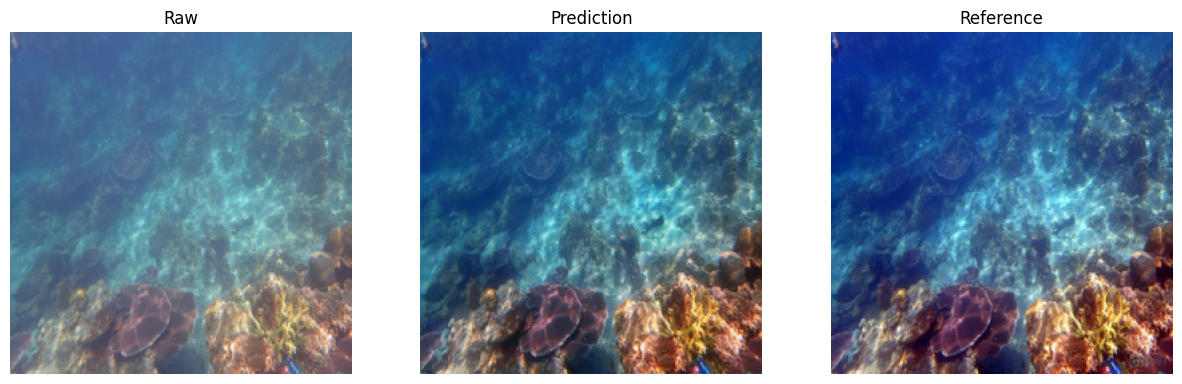

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def format_for_plot(img):
    if torch.is_tensor(img):
        img = img.detach().cpu().permute(1, 2, 0).numpy()
    elif isinstance(img, np.ndarray) and img.shape[0] == 3:
        img = img.transpose(1, 2, 0)
    return np.clip(img, 0, 1)

raw = format_for_plot(raw_imgs[0])
pred = format_for_plot(outputs[0])
target = format_for_plot(ref_imgs[0])

axes[0].imshow(raw)
axes[0].set_title("Raw")
axes[0].axis("off")

axes[1].imshow(pred)
axes[1].set_title("Prediction")
axes[1].axis("off")

axes[2].imshow(target)
axes[2].set_title("Reference")
axes[2].axis("off")

plt.show()